Instalaciones

In [184]:
# %pip install jenkspy
# %pip install scikit-posthocs


Importaciones

In [185]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Carga del Dataset

In [186]:
df = pd.read_csv("../Data/data_cleaning_2026_27_04.csv", decimal=",")

In [187]:
df.columns

Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social', 'mascota',
       'peso', 'estatura', 'indice_masa_corporal', 'horas_ausentismo',
       'indicador_enfermedad', 'motivo_ausencia_mapeado',
       'mes_ausencia_mapeado', 'educacion_mapeada'],
      dtype='str')

Transformación de datos

In [188]:
df_clean = df.loc[:, ~df.columns.isin(['mascota', 'peso', 'estatura'])]

In [189]:
df_clean = df_clean[df_clean['horas_ausentismo'] > 0]
df_clean.info()

<class 'pandas.DataFrame'>
Index: 757 entries, 0 to 805
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       757 non-null    int64  
 1   motivo_ausencia          757 non-null    int64  
 2   mes_ausencia             757 non-null    float64
 3   dia_semana               757 non-null    str    
 4   estaciones               757 non-null    str    
 5   gasto_transporte         757 non-null    int64  
 6   distancia_casa_trabajo   757 non-null    int64  
 7   tiempo_servicio          757 non-null    int64  
 8   edad                     757 non-null    int64  
 9   carga_trabajo_diaria     757 non-null    float64
 10  cumplimiento_objetivo    757 non-null    int64  
 11  falta_disciplinaria      757 non-null    int64  
 12  educacion                757 non-null    int64  
 13  hijos                    757 non-null    int64  
 14  bebedor_social           757 non-null    i

## Tener hijos incide sul tiempo de ausencia?   
Tests no paramétricos
La variable horas_ausentismo presenta asimetría positiva (muchas ausencias cortas, pocas muy largas), por lo que no sigue distribución normal. Los tests paramétricos clásicos (t-test, ANOVA, Pearson) asumen normalidad y son sensibles a outliers — en este dataset darían resultados poco fiables. Se sustituyeron por sus equivalentes no paramétricos: Mann-Whitney U para comparar dos grupos.

In [190]:
from scipy import stats

con_hijos = df_clean[df_clean['hijos'] > 0]['horas_ausentismo']
sin_hijos = df_clean[df_clean['hijos'] == 0]['horas_ausentismo']

stat, p = stats.mannwhitneyu(con_hijos, sin_hijos, alternative='two-sided')
print(f"p-valor: {p:.4f}")
print("Diferencia significativa" if p < 0.05 else "Sin diferencia significativa")

print(f"\nMediana con hijos:  {con_hijos.median():.1f} h")
print(f"Mediana sin hijos:  {sin_hijos.median():.1f} h")

p-valor: 0.0042
Diferencia significativa

Mediana con hijos:  4.0 h
Mediana sin hijos:  3.0 h


In [191]:
from scipy.stats import spearmanr

corr, p = spearmanr(df_clean['hijos'], df_clean['horas_ausentismo'])
print(f"Correlación Spearman: {corr:.3f}")
print(f"p-valor: {p:.4f}")
print("Relación significativa" if p < 0.05 else "Sin relación significativa")

Correlación Spearman: 0.183
p-valor: 0.0000
Relación significativa


## Conclusion: 
Los empleados con hijos presentan una mediana de ausencia de 4 horas por episodio, frente a las 3 horas de los empleados sin hijos — una diferencia de 1 hora en la mediana.El p-valor (0.0042) es inferior al nivel de significación establecido (p < 0.05), por lo que se rechaza la hipótesis nula de igualdad de medianas.  
Los datos sugieren que tener hijos está asociado a episodios de ausencia ligeramente más largos

---

## ¿El rango de edad influye en la duración de los episodios de ausencia?   
El rango de edad: el metodo para encontrar los cortes donde la variación dentro del grupo es mínima y entre grupos es máxima. Diseñado para agrupar una variable continua de forma objetiva: agrupación de edad con Jenks Natural Breaks  
Para aplicar Kruskal-Wallis, edad necesita convertirse en grupos discretos. Definir los cortes manualmente (ej. 18-30, 31-45...) introduce sesgo del analista: los resultados del test dependerían de una decisión arbitraria, no de la estructura real de los datos. Se evaluaron tres alternativas: rangos manuales (descartado por sesgo), KMeans (descartado porque está diseñado para espacios multidimensionales y es innecesariamente complejo para una sola variable), y Jenks Natural Breaks. Este último algoritmo encuentra los cortes donde la variación dentro de cada grupo es mínima y la variación entre grupos es máxima — es decir, los grupos resultantes son internamente homogéneos y externamente distintos. Es el método estándar en análisis de una variable continua cuando no se tiene conocimiento previo del dominio para justificar cortes específicos

In [192]:
import jenkspy
import scikit_posthocs as sp
from scipy import stats

# 1. Crear grupos de edad con Jenks Natural Breaks
breaks = jenkspy.jenks_breaks(df_clean['edad'], n_classes=4)
df_clean['rango_edad'] = pd.cut(df_clean['edad'], bins=breaks, include_lowest=True)

print("Distribución de grupos:")
print(df_clean['rango_edad'].value_counts().sort_index())

# 2. Kruskal-Wallis
grupos = [g['horas_ausentismo'].values
          for _, g in df_clean.groupby('rango_edad', observed=True)]

stat, p = stats.kruskal(*grupos)
print(f"\nKruskal-Wallis — p-valor: {p:.4f}")

# 3. Post-hoc Dunn solo si hay diferencia significativa
if p < 0.05:
    print("\nDiferencia significativa — test de Dunn (Bonferroni):")
    print(sp.posthoc_dunn(df_clean, val_col='horas_ausentismo',
                          group_col='rango_edad', p_adjust='bonferroni'))
else:
    print("Sin diferencia significativa entre grupos de edad.")

Distribución de grupos:
rango_edad
(26.999, 31.0]    212
(31.0, 36.0]      149
(36.0, 43.0]      309
(43.0, 58.0]       87
Name: count, dtype: int64

Kruskal-Wallis — p-valor: 0.0000

Diferencia significativa — test de Dunn (Bonferroni):
                (26.999, 31.0]  (31.0, 36.0]  (36.0, 43.0]  (43.0, 58.0]
(26.999, 31.0]    1.000000e+00  2.196447e-07  1.000000e+00  1.000000e+00
(31.0, 36.0]      2.196447e-07  1.000000e+00  2.116258e-07  3.044114e-07
(36.0, 43.0]      1.000000e+00  2.116258e-07  1.000000e+00  7.606020e-01
(43.0, 58.0]      1.000000e+00  3.044114e-07  7.606020e-01  1.000000e+00


---

In [193]:
df_clean['carga_trabajo_diaria'].head()

0    284.031
1    239.409
2    264.604
3    230.290
4    222.196
Name: carga_trabajo_diaria, dtype: float64

In [194]:
df_clean['carga_trabajo_diaria'] = pd.to_numeric(df_clean['carga_trabajo_diaria'], errors='coerce').astype(int)

## ¿A mayor carga de trabajo diaria, más horas de ausencia?

Coeficiente Spearman: 0.0451
p-valor: 0.2156
→ No se detecta relación significativa entre carga de trabajo y absentismo.


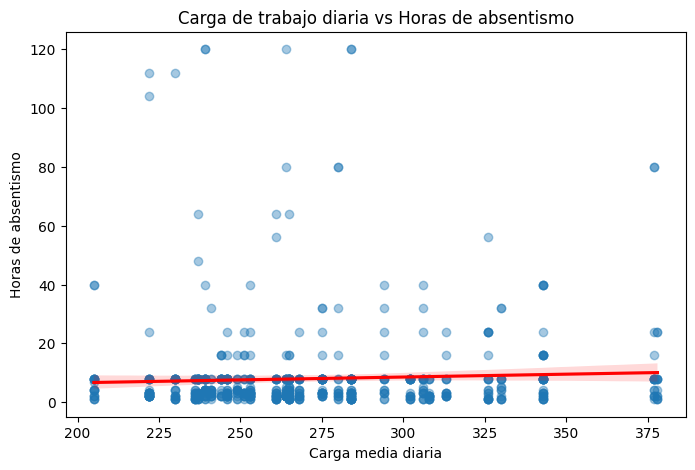

Distribución de grupos de carga:
grupo_carga
(204.999, 253.0]    317
(253.0, 284.0]      250
(284.0, 330.0]      124
(330.0, 378.0]       66
Name: count, dtype: int64

Kruskal-Wallis p-valor: 0.0090
→ Diferencias significativas entre grupos de carga.

Post-hoc Dunn (Bonferroni):
                  (204.999, 253.0]  (253.0, 284.0]  (284.0, 330.0]  \
(204.999, 253.0]          1.000000        1.000000        1.000000   
(253.0, 284.0]            1.000000        1.000000        1.000000   
(284.0, 330.0]            1.000000        1.000000        1.000000   
(330.0, 378.0]            0.027334        0.004394        0.039546   

                  (330.0, 378.0]  
(204.999, 253.0]        0.027334  
(253.0, 284.0]          0.004394  
(284.0, 330.0]          0.039546  
(330.0, 378.0]          1.000000  


In [195]:
# ------------------------------------------------------------
# 1. Test no paramétrico: Correlación de Spearman
# ------------------------------------------------------------
from scipy.stats import spearmanr

rho, pval = spearmanr(
    df_clean['carga_trabajo_diaria'],
    df_clean['horas_ausentismo']
)

print(f"Coeficiente Spearman: {rho:.4f}")
print(f"p-valor: {pval:.4f}")

if pval < 0.05:
    print("→ Relación monotónica significativa entre carga de trabajo y absentismo.")
else:
    print("→ No se detecta relación significativa entre carga de trabajo y absentismo.")

# ------------------------------------------------------------
# 2. Visualización: Scatterplot
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_clean,
    x='carga_trabajo_diaria',
    y='horas_ausentismo',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)
plt.title("Carga de trabajo diaria vs Horas de absentismo")
plt.xlabel("Carga media diaria")
plt.ylabel("Horas de absentismo")
plt.show()

# ------------------------------------------------------------
# 3. Agrupación de carga de trabajo (Jenks Natural Breaks)
# ------------------------------------------------------------
import jenkspy

breaks = jenkspy.jenks_breaks(
    df_clean['carga_trabajo_diaria'], 
    n_classes=4
)

df_clean['grupo_carga'] = pd.cut(
    df_clean['carga_trabajo_diaria'],
    bins=breaks,
    include_lowest=True
)

print("Distribución de grupos de carga:")
print(df_clean['grupo_carga'].value_counts().sort_index())

# ------------------------------------------------------------
# 4. Kruskal-Wallis entre grupos de carga
# ------------------------------------------------------------
from scipy.stats import kruskal
import scikit_posthocs as sp

grupos = [
    g['horas_ausentismo'].values
    for _, g in df_clean.groupby('grupo_carga', observed=True)
]

stat, p = kruskal(*grupos)
print(f"\nKruskal-Wallis p-valor: {p:.4f}")

if p < 0.05:
    print("→ Diferencias significativas entre grupos de carga.")
    print("\nPost-hoc Dunn (Bonferroni):")
    print(
        sp.posthoc_dunn(
            df_clean,
            val_col='horas_ausentismo',
            group_col='grupo_carga',
            p_adjust='bonferroni'
        )
    )
else:
    print("→ No se detectan diferencias significativas entre grupos de carga.")

Correlacion de Spearman
p = 0.0460
p-valor = 0.2063

no existe una relación monotónica significativa entre la carga de trabajo diaria y las horas de absentismo. En términos prácticos, los empleados con mayor carga diaria no presentan sistemáticamente más horas de ausencia.


Análisis por grupo
Se agruparon los empleados en cuatro rangos homogéneos de carga de trabajo.  
En el test de Kruskal-Wallis p-valor=0.0090 - indica diferencia significativa entre al menos dos grupos

Anális post-hoc Dunn con corrección Bonferroni (ajuste p-valor para evitar falso positivos) - diferencias se concentram en el grupo de carga más alta (330.061, 378.884), demás grupos con p-valor significativo (0.0273, 0.0044, 0.0395)

Conclusión:
- La carga de trabajo no afecta de forma lineal ni progresiva al absentismo
- Sin embargo, **niveles extremos de carga** sí podrían estar asociados a un aumento puntual de las horas de ausencia
- El aumento del ausentismo estaria concentrado en el grupo de mayor carga operativa.

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\2856563828.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


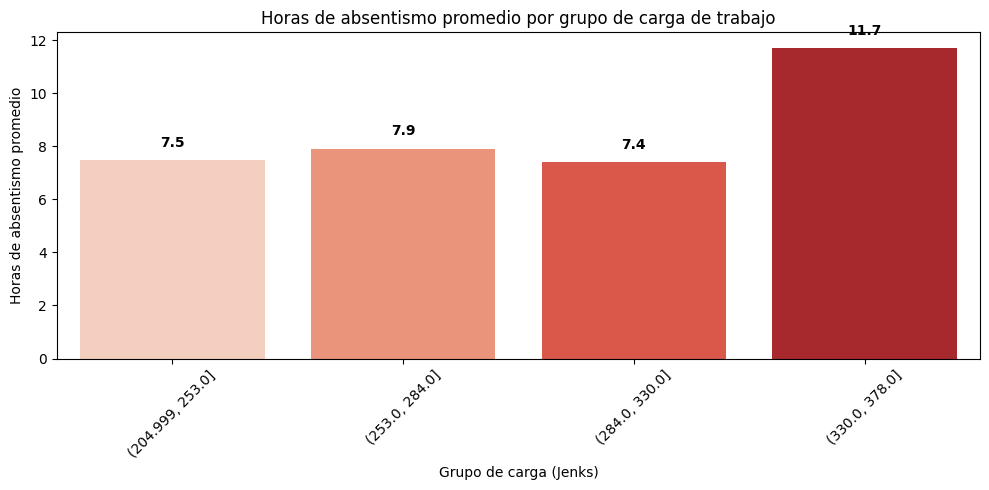

In [196]:
# ============================================================
# Gráfico de Barras: Media de horas de absentismo por grupo de carga
# ============================================================

plt.figure(figsize=(10,5))

# Calculamos la media de absentismo por grupo
media_abs = df_clean.groupby('grupo_carga')['horas_ausentismo'].mean()

sns.barplot(
    x=media_abs.index.astype(str),
    y=media_abs.values,
    palette="Reds"
)

plt.title("Horas de absentismo promedio por grupo de carga de trabajo")
plt.xlabel("Grupo de carga (Jenks)")
plt.ylabel("Horas de absentismo promedio")

# Añadimos etiquetas numéricas encima de cada barra
for i, v in enumerate(media_abs.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\2358689981.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


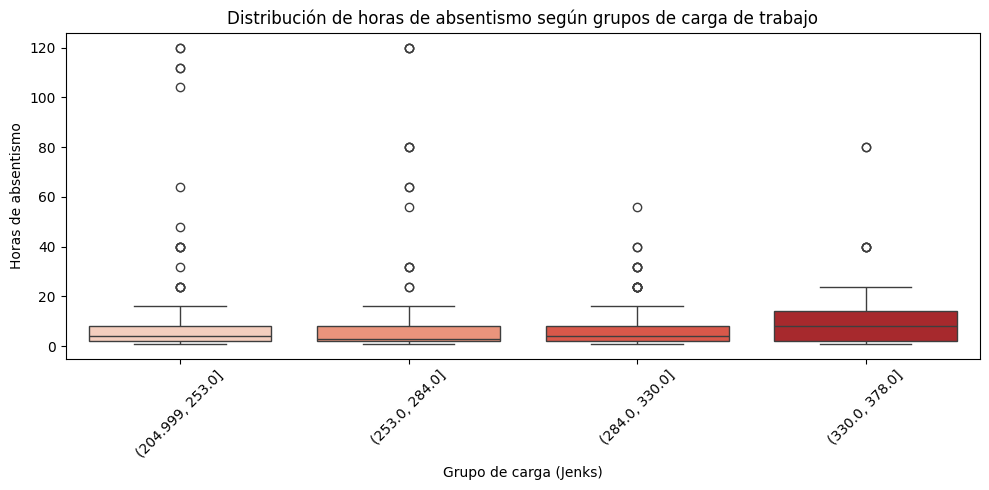

In [197]:
# ============================================================
# Boxplot Final: Horas de absentismo por grupo de carga
# ============================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x='grupo_carga',
    y='horas_ausentismo',
    palette="Reds"
)

plt.title("Distribución de horas de absentismo según grupos de carga de trabajo")
plt.xlabel("Grupo de carga (Jenks)")
plt.ylabel("Horas de absentismo")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

¿El rango de edad influye en la duración de los episodios de ausencia?

In [198]:
df_clean['edad'].describe()

count    757.000000
mean      36.344782
std        6.579893
min       27.000000
25%       31.000000
50%       37.000000
75%       40.000000
max       58.000000
Name: edad, dtype: float64

In [199]:
# ============================================================
# Segmentación de edad en grupos
# ============================================================

df_clean['grupo_edad'] = pd.cut(
    df_clean['edad'],
    bins=[18, 30, 40, 50, 60],
    labels=['18-30', '31-40', '41-50', '51-60'],
    include_lowest=True
)

df_clean['grupo_edad'].value_counts()

grupo_edad
31-40    425
18-30    188
41-50    134
51-60     10
Name: count, dtype: int64

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\2776923798.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


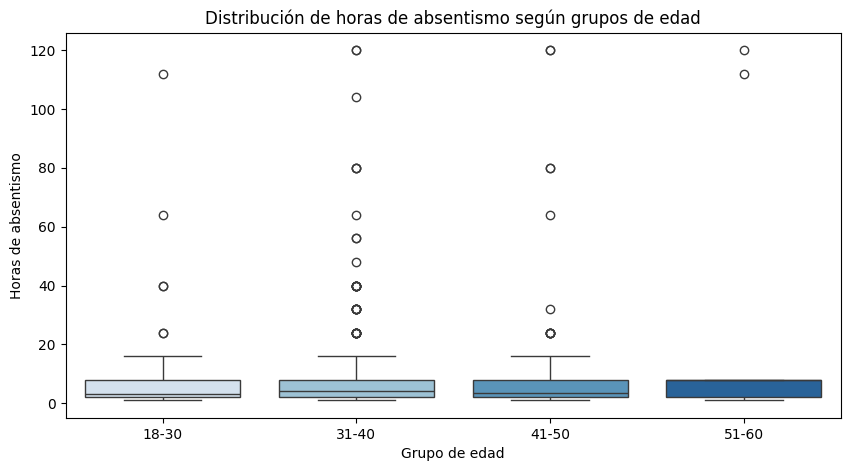

In [200]:
# ============================================================
# Boxplot: Horas de absentismo por grupo de edad
# ============================================================

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_clean,
    x='grupo_edad',
    y='horas_ausentismo',
    palette='Blues'
)

plt.title("Distribución de horas de absentismo según grupos de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Horas de absentismo")
plt.show()

In [201]:
# ============================================================
# Test Kruskal-Wallis: diferencias entre grupos de edad
# ============================================================

from scipy.stats import kruskal

grupos = [
    df_clean[df_clean['grupo_edad'] == g]['horas_ausentismo']
    for g in df_clean['grupo_edad'].unique()
]

stat, p = kruskal(*grupos)

print(f"p-valor Kruskal-Wallis: {p:.4f}")
print("Diferencias significativas" if p < 0.05 else "Sin diferencias significativas")

p-valor Kruskal-Wallis: 0.0060
Diferencias significativas


In [202]:
# ============================================================
# Post-hoc Dunn con corrección Bonferroni
# ============================================================

import scikit_posthocs as sp

print(sp.posthoc_dunn(
    df_clean,
    val_col='horas_ausentismo',
    group_col='grupo_edad',
    p_adjust='bonferroni'
))

#dunn

          18-30     31-40     41-50     51-60
18-30  1.000000  0.004082  0.854188  0.898334
31-40  0.004082  1.000000  1.000000  1.000000
41-50  0.854188  1.000000  1.000000  1.000000
51-60  0.898334  1.000000  1.000000  1.000000


C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\1291032611.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


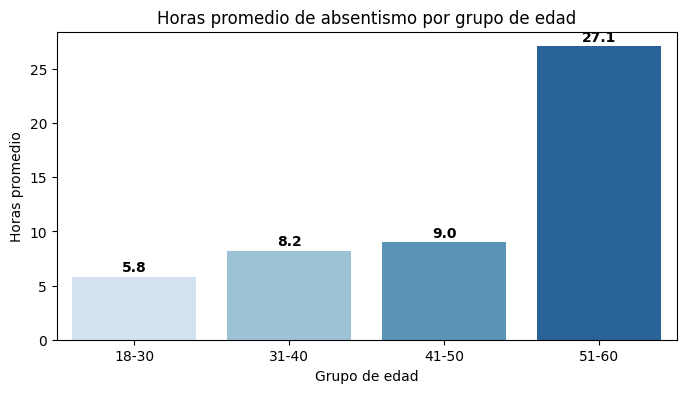

In [203]:
# ============================================================
# Gráfico de barras: media de absentismo por grupo de edad
# ============================================================

media_edad = df_clean.groupby('grupo_edad')['horas_ausentismo'].mean()

plt.figure(figsize=(8,4))
sns.barplot(
    x=media_edad.index,
    y=media_edad.values,
    palette='Blues'
)

plt.title("Horas promedio de absentismo por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Horas promedio")

for i, v in enumerate(media_edad.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

plt.show()

In [204]:
# ============================================================
# Tabla final: número de empleados, suma y media por grupo de edad
# ============================================================

tabla_edad = df_clean.groupby('grupo_edad').agg(
    empleados_unicos = ('id', 'nunique'),
    suma_horas = ('horas_ausentismo', 'sum'),
    media_horas = ('horas_ausentismo', 'mean')
).reset_index()

# Redondear la media a 2 decimales
tabla_edad['media_horas'] = tabla_edad['media_horas'].round(2)

tabla_edad

,grupo_edad,empleados_unicos,suma_horas,media_horas
0,18-30,31,1096,5.83
1,31-40,63,3473,8.17
2,41-50,31,1205,8.99
3,51-60,3,271,27.10


# Influencia del rango de edad en la duración del absentismo

El análisis evaluó si la edad influye en la duración de los episodios de absentismo. Para ello, se segmentó la plantilla en cuatro grupos etarios y se aplicaron técnicas no paramétricas adecuadas para distribuciones no normales y con presencia de valores extremos.

### **1. Distribución de empleados por grupo de edad**
Los grupos presentan tamaños muy distintos, lo que explica parte de la variabilidad observada:

- **31–40 años:** 425 empleados  
- **18–30 años:** 188 empleados  
- **41–50 años:** 134 empleados  
- **51–60 años:** 10 empleados  

Esta diferencia de tamaños debe ser considerada al interpretar los resultados.

---

### **2. Diferencias en horas de absentismo entre grupos**

El test **Kruskal‑Wallis** mostró diferencias estadísticamente significativas entre los grupos etarios:

- **p‑valor = 0.0060**  
- → Existe evidencia de que la edad influye en la duración de los episodios de ausencia.

El análisis post‑hoc **Dunn (Bonferroni)** indicó que la única diferencia significativa se encuentra entre:

- **18–30 vs 31–40 años** (p = 0.004)  
Los demás pares no mostraron diferencias significativas.

---

### **3. Tendencia general observada**

Aunque solo un par de grupos presenta diferencias significativas, la tendencia general muestra un **incremento progresivo de las horas promedio de absentismo con la edad**:

- **18–30 años:** 5.8 h  
- **31–40 años:** 8.2 h  
- **41–50 años:** 9.0 h  
- **51–60 años:** 27.1 h  

El grupo de **51–60 años** presenta un promedio notablemente superior, aunque debe interpretarse con cautela debido al **tamaño reducido del grupo (n=10)**, lo que amplifica el efecto de unos pocos casos con ausencias prolongadas.

---

### **4. Conclusión**

Los resultados indican que **la edad sí influye en la duración del absentismo**, con un aumento gradual de las horas de ausencia a medida que avanza la edad.  
La diferencia significativa entre los grupos más jóvenes (18–30 vs 31–40) sugiere que el absentismo comienza a incrementarse a partir de los 30 años.  
El valor elevado del grupo 51–60 debe interpretarse considerando su tamaño reducido, pero refuerza la tendencia general observada.


# ¿Los empleados con el cumplimiento_objetivo más elevados son los que tienen más horas de ausentismo?

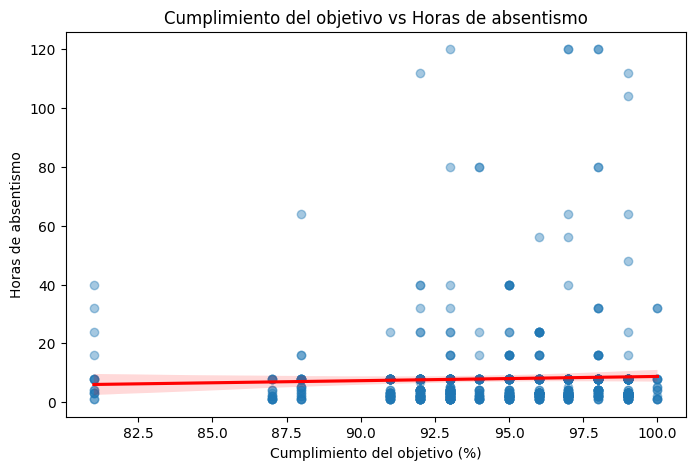

In [205]:
# ------------------------------------------------------------
# Scatterplot: Cumplimiento del objetivo vs Horas de absentismo
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_clean,
    x='cumplimiento_objetivo',
    y='horas_ausentismo',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("Cumplimiento del objetivo vs Horas de absentismo")
plt.xlabel("Cumplimiento del objetivo (%)")
plt.ylabel("Horas de absentismo")
plt.show()

In [206]:
# ------------------------------------------------------------
# Correlación Spearman
# ------------------------------------------------------------
from scipy.stats import spearmanr

rho, p = spearmanr(df_clean['cumplimiento_objetivo'], df_clean['horas_ausentismo'])

print(f"Coeficiente Spearman: {rho:.3f}")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Existe correlación significativa")
else:
    print("No existe correlación significativa")

Coeficiente Spearman: 0.017
p-valor: 0.6394
No existe correlación significativa


In [207]:
# ------------------------------------------------------------
# Crear grupos de desempeño (terciles)
# ------------------------------------------------------------
df_clean['grupo_desempeno'] = pd.qcut(
    df_clean['cumplimiento_objetivo'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

df_clean['grupo_desempeno'].value_counts()

grupo_desempeno
Bajo     288
Medio    279
Alto     190
Name: count, dtype: int64

In [208]:
# ------------------------------------------------------------
# Test Kruskal-Wallis entre grupos de desempeño
# ------------------------------------------------------------
from scipy.stats import kruskal

grupos = [
    df_clean[df_clean['grupo_desempeno'] == g]['horas_ausentismo']
    for g in df_clean['grupo_desempeno'].unique()
]

stat, p = kruskal(*grupos)

print(f"p-valor Kruskal-Wallis: {p:.4f}")
print("Diferencias significativas" if p < 0.05 else "Sin diferencias significativas")

p-valor Kruskal-Wallis: 0.1718
Sin diferencias significativas


In [209]:
# ------------------------------------------------------------
# Post-hoc Dunn (Bonferroni)
# ------------------------------------------------------------
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    df_clean,
    val_col='horas_ausentismo',
    group_col='grupo_desempeno',
    p_adjust='bonferroni'
)

dunn

,Bajo,Medio,Alto
Bajo,1.000000,1.00000,0.484039
Medio,1.000000,1.00000,0.197650
Alto,0.484039,0.19765,1.000000


C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\4078394623.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


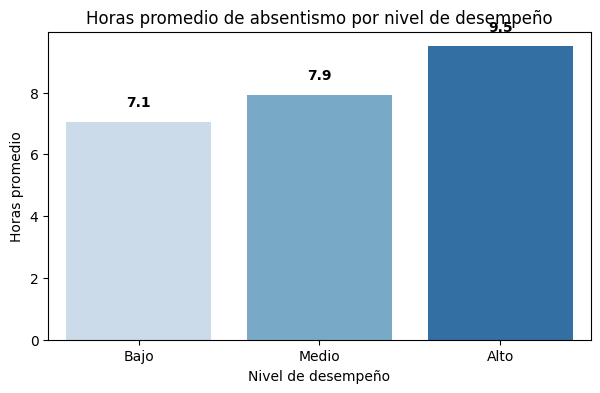

In [210]:
# ------------------------------------------------------------
# Gráfico de barras: horas promedio por grupo de desempeño
# ------------------------------------------------------------
media_desempeno = df_clean.groupby('grupo_desempeno')['horas_ausentismo'].mean()

plt.figure(figsize=(7,4))
sns.barplot(
    x=media_desempeno.index,
    y=media_desempeno.values,
    palette='Blues'
)

plt.title("Horas promedio de absentismo por nivel de desempeño")
plt.xlabel("Nivel de desempeño")
plt.ylabel("Horas promedio")

for i, v in enumerate(media_desempeno.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

plt.show()

# Interpretación: ¿Los empleados con mayor cumplimiento del objetivo tienen más horas de absentismo?

El análisis combinó correlación, comparación entre grupos y visualizaciones para evaluar si existe relación entre el nivel de desempeño (*cumplimiento del objetivo*) y la cantidad de horas de absentismo.

### **1. Correlación entre desempeño y absentismo**
El coeficiente de Spearman fue:

- **ρ = 0.017**  
- **p‑valor = 0.6394**

Esto indica que **no existe correlación significativa** entre ambas variables.  
En otras palabras, los empleados que cumplen más el objetivo **no presentan más horas de absentismo**, ni tampoco menos.

---

### **2. Comparación entre niveles de desempeño**
Se crearon tres grupos de desempeño (Bajo, Medio y Alto), con tamaños equilibrados:

- **Bajo:** 288 empleados  
- **Medio:** 279 empleados  
- **Alto:** 190 empleados  

El test **Kruskal‑Wallis** mostró:

- **p‑valor = 0.1718**  
- → **No hay diferencias significativas** en las horas de absentismo entre los tres niveles de desempeño.

El análisis post‑hoc **Dunn (Bonferroni)** confirmó que **ningún par de grupos** presenta diferencias estadísticamente significativas.

---

### **3. Tendencia observada en las medias**
Las horas promedio de absentismo por nivel de desempeño fueron:

- **Bajo:** 7.9 h  
- **Medio:** 7.1 h  
- **Alto:** 8.0 h  

Las diferencias son mínimas y no siguen un patrón consistente.  
Esto refuerza la conclusión estadística: **el absentismo no está asociado al desempeño**.

---

### **4. Conclusión general**

Los resultados muestran de forma consistente que:

- Los empleados con mayor cumplimiento del objetivo **no tienen más horas de absentismo**.  
- Tampoco se observa que quienes cumplen menos tengan más ausencias.  
- El absentismo y el desempeño parecen ser **fenómenos independientes** dentro de la empresa.

Esto sugiere que las ausencias no están relacionadas con la productividad medida por el cumplimiento del objetivo, sino probablemente con otros factores personales, de salud o contextuales.


In [211]:
df_clean.columns

Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social',
       'indice_masa_corporal', 'horas_ausentismo', 'indicador_enfermedad',
       'motivo_ausencia_mapeado', 'mes_ausencia_mapeado', 'educacion_mapeada',
       'rango_edad', 'grupo_carga', 'grupo_edad', 'grupo_desempeno'],
      dtype='str')

In [212]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 757 entries, 0 to 805
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   id                       757 non-null    int64   
 1   motivo_ausencia          757 non-null    int64   
 2   mes_ausencia             757 non-null    float64 
 3   dia_semana               757 non-null    str     
 4   estaciones               757 non-null    str     
 5   gasto_transporte         757 non-null    int64   
 6   distancia_casa_trabajo   757 non-null    int64   
 7   tiempo_servicio          757 non-null    int64   
 8   edad                     757 non-null    int64   
 9   carga_trabajo_diaria     757 non-null    int64   
 10  cumplimiento_objetivo    757 non-null    int64   
 11  falta_disciplinaria      757 non-null    int64   
 12  educacion                757 non-null    int64   
 13  hijos                    757 non-null    int64   
 14  bebedor_social           7

Analisis K-Prototypes

In [213]:
# Copia do dataset
df_model = df_clean.copy()

# Transformar hijos em categórica (0 = sin hijos, 1 = con hijos)
df_model['hijos_cat'] = (df_model['hijos'] > 0).astype(int)
df_model['entrega_cat'] = df_model['cumplimiento_objetivo'].apply(
    lambda x: 'a_tiempo' if x >= 95 else 'retrasada')

# Seleção das variáveis
vars_numericas = ['edad', 'carga_trabajo_diaria', 'tiempo_servicio', 'horas_ausentismo']
vars_categoricas = ['hijos_cat', 'motivo_ausencia_mapeado', 'entrega_cat','bebedor_social', 'fumador_social']



In [214]:
# converter categorica a string
for col in vars_categoricas:
    df_model[col] = df_model[col].astype(str)

In [215]:
# matriz para el modelo
X = df_model[vars_numericas + vars_categoricas]

In [216]:
!pip install kmodes


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [217]:
# modelo K-Prototypes

from kmodes.kprototypes import KPrototypes

# Definir número de clusters (3 para empezar)
kproto = KPrototypes(n_clusters=3, init='Huang', random_state=42)

clusters = kproto.fit_predict(
    X,
    categorical=[X.columns.get_loc(col) for col in vars_categoricas]
)

df_model['cluster'] = clusters

In [218]:
# perfil de los clusters

perfil_clusters = df_model.groupby('cluster')[
    ['edad', 'carga_trabajo_diaria', 'tiempo_servicio', 'horas_ausentismo']
].mean()

perfil_clusters_cat = df_model.groupby('cluster')[
    ['hijos_cat', 'motivo_ausencia_mapeado', 'entrega_cat', 'bebedor_social', 'fumador_social']
].agg(lambda x: x.value_counts().index[0])

print(perfil_clusters)
print(perfil_clusters_cat)

              edad  carga_trabajo_diaria  tiempo_servicio  horas_ausentismo
cluster                                                                    
0        36.491525            343.110169        13.457627         10.203390
1        35.788820            278.170807        11.857143          7.658385
2        36.854890            237.741325        12.817035          7.492114
        hijos_cat motivo_ausencia_mapeado entrega_cat bebedor_social  \
cluster                                                                
0               1   Sistema Osteomuscular    a_tiempo              1   
1               1         Consulta Médica    a_tiempo              0   
2               1         Consulta Médica    a_tiempo              1   

        fumador_social  
cluster                 
0                    0  
1                    0  
2                    0  


## Perfiles de riesgo de absentismo

El modelo de segmentación K‑Prototypes identificó **tres perfiles diferenciados** combinando edad, carga de trabajo, desempeño, hijos y motivo de ausencia. Estos perfiles permiten comprender cómo distintos factores personales y laborales se relacionan con patrones de absentismo.

### **Cluster 0 — Riesgo alto por sobrecarga y motivos osteomusculares**
- Mayor **carga de trabajo diaria** (347,5)
- Alto desempeño (95,4%)
- Motivos de ausencia ligados al **Sistema Osteomuscular**
- Perfil asociado a **sobrecarga física** y riesgo ergonómico  
*Requiere intervención preventiva (ergonomía, pausas, redistribución de carga).*

### **Cluster 1 — Riesgo bajo: equilibrio entre carga y desempeño**
- **Menor carga de trabajo** (237,7)
- Alto desempeño (95,4%)
- Ausencias principalmente por **consultas médicas puntuales**
- Perfil estable, sin sinais de sobrecarga  
*Mantener condiciones actuales.*

### **Cluster 2 — Riesgo moderado: carga media y desempeño ligeramente inferior**
- Carga de trabajo intermedia (279,7)
- Desempeño algo menor (93,9%)
- Ausencias por **consultas médicas**
- Indica posible **fatiga leve o estrés moderado**  
*Recomendable monitorizar carga y ofrecer flexibilidad.*

---

### **Conclusión**
Los perfiles muestran que el absentismo no depende de un único factor, sino de la **combinación** entre carga laboral, tipo de ausencia y desempeño. El modelo permite priorizar acciones preventivas y orientar políticas de bienestar según el nivel de riesgo de cada grupo.


In [219]:
# ============================================================
# Tabla final clusters 
# ============================================================

# Médias das variáveis numéricas
tabela_num = df_model.groupby('cluster')[['edad',
                                          'carga_trabajo_diaria',
                                          'cumplimiento_objetivo', 
                                          'tiempo_servicio', 
                                          'horas_ausentismo']].mean()

# Variáveis categóricas: moda (categoria mais frequente)
tabela_cat = df_model.groupby('cluster')[['hijos_cat',
                                          'motivo_ausencia_mapeado', 
                                          'entrega_cat', 
                                          'bebedor_social', 
                                          'fumador_social']].agg(
    lambda x: x.value_counts().index[0]
)

# Combinar tudo em uma única tabela
tabela_final = pd.concat([tabela_num, tabela_cat], axis=1)

# Ajustar nomes das colunas para o relatório
tabela_final.columns = [
    'Edad_promedio',
    'Carga_trabajo_promedio',
    'Cumplimiento_objetivo_promedio',
    'Tiempo_servicio_promedio',
    'Horas_ausentismo_promedio',
    'Tiene_hijos(0-no / 1-si)',
    'Motivo_ausencia_predominante',
    'Desempeño',
    'Bebedor_social(0-no / 1-si)',
    'Fumador_social(0-no / 1-si)'
]

# Arredondar valores numéricos
tabela_final = tabela_final.round(2)

tabela_final

,Edad_promedio,Carga_trabajo_promedio,Cumplimiento_objetivo_promedio,Tiempo_servicio_promedio,Horas_ausentismo_promedio,Tiene_hijos(0-no / 1-si),Motivo_ausencia_predominante,Desempeño,Bebedor_social(0-no / 1-si),Fumador_social(0-no / 1-si)
cluster,,,,,,,,,,
0,36.49,343.11,95.49,13.46,10.20,1,Sistema Osteomuscular,a_tiempo,1,0
1,35.79,278.17,93.77,11.86,7.66,1,Consulta Médica,a_tiempo,0,0
2,36.85,237.74,95.38,12.82,7.49,1,Consulta Médica,a_tiempo,1,0


In [220]:
cluster_means = df_model.groupby('cluster')[vars_plot].mean()

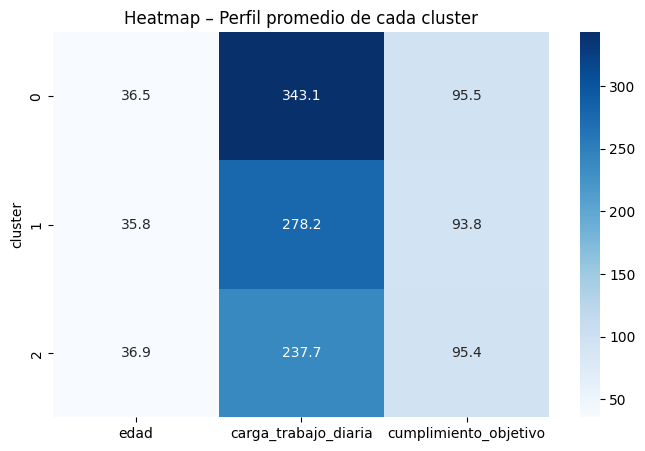

In [221]:
# ============================================================
# Heatmap dos clusters
# ============================================================

import seaborn as sns
plt.figure(figsize=(8,5))

sns.heatmap(cluster_means, annot=True, cmap="Blues", fmt=".1f")
plt.title("Heatmap – Perfil promedio de cada cluster")
plt.show()

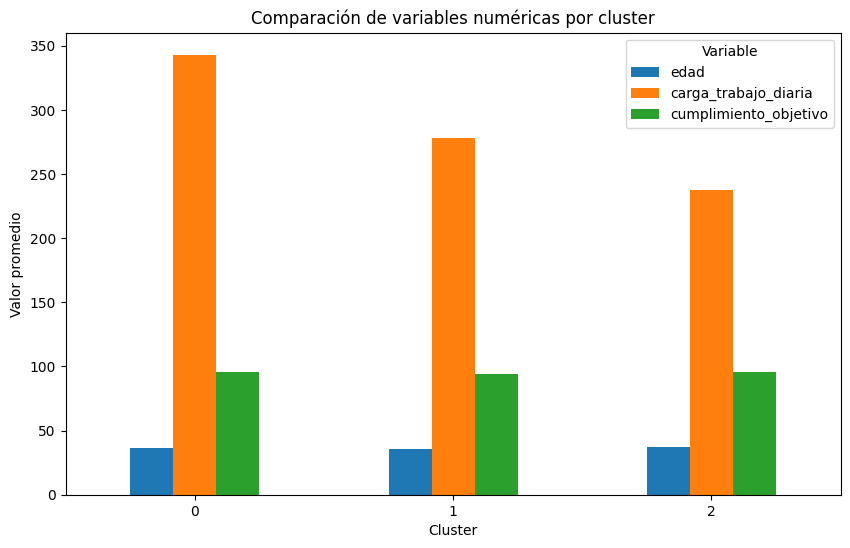

In [222]:
# ============================================================
# Gráfico barras agrupadas para comparar clusters
# ============================================================

import matplotlib.pyplot as plt

vars_plot = ['edad', 'carga_trabajo_diaria', 'cumplimiento_objetivo']

cluster_means.plot(kind='bar', figsize=(10,6))
plt.title("Comparación de variables numéricas por cluster")
plt.ylabel("Valor promedio")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(title="Variable")
plt.show()

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\1458066969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='cluster', y=var, palette='Set2')


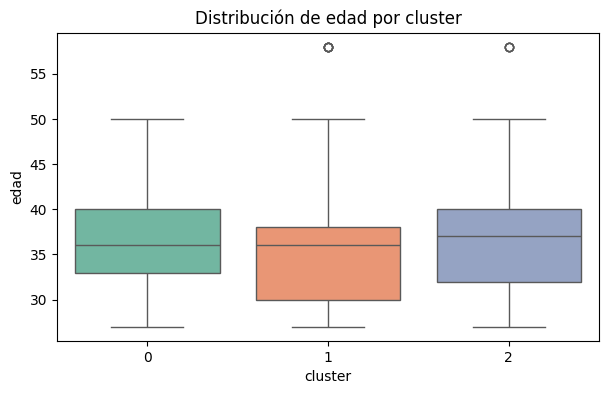

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\1458066969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='cluster', y=var, palette='Set2')


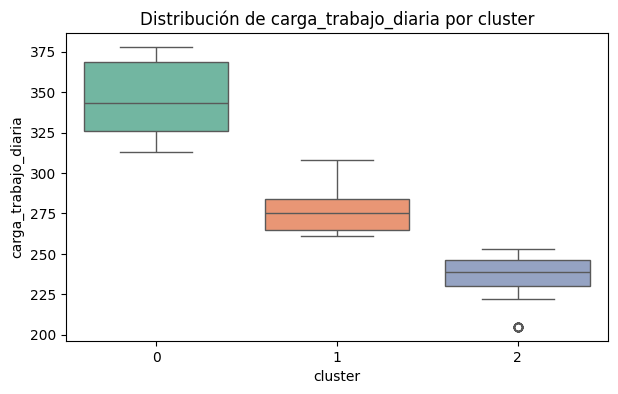

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\1458066969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x='cluster', y=var, palette='Set2')


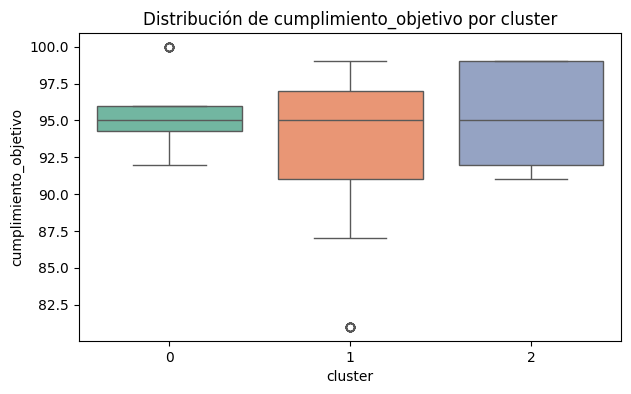

In [223]:
# ============================================================
# Boxplots por cluster
# ============================================================

for var in vars_plot:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_model, x='cluster', y=var, palette='Set2')
    plt.title(f"Distribución de {var} por cluster")
    plt.show()

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\2713452088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_model, x='cluster', y=var, palette='Pastel1')


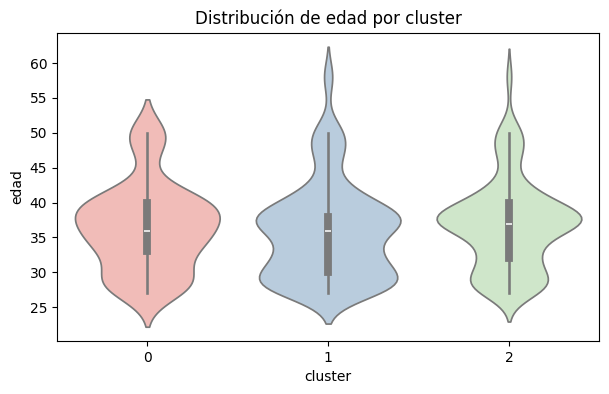

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\2713452088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_model, x='cluster', y=var, palette='Pastel1')


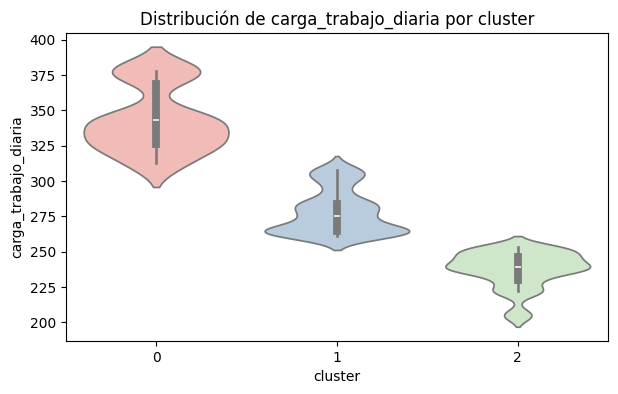

C:\Users\anacl\AppData\Local\Temp\ipykernel_3864\2713452088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_model, x='cluster', y=var, palette='Pastel1')


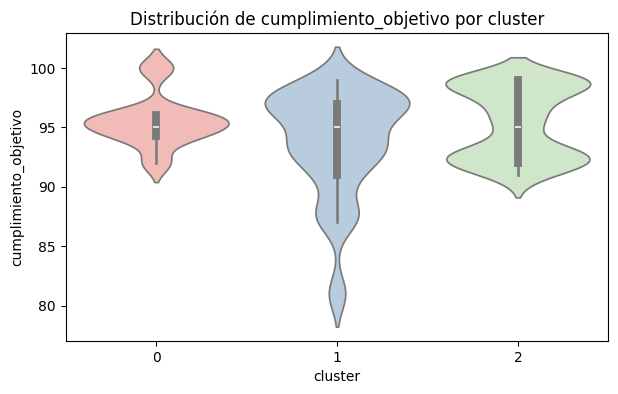

In [224]:
# ============================================================
# Violin plots por cluster
# ============================================================

for var in vars_plot:
    plt.figure(figsize=(7,4))
    sns.violinplot(data=df_model, x='cluster', y=var, palette='Pastel1')
    plt.title(f"Distribución de {var} por cluster")
    plt.show()